In [ ]:
using Pkg
Pkg.activate("../.")
using Plots, CairoMakie, LaTeXStrings 

  Activating project at `~/github/FisheriesInsuranceModel`
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]
Precompiling CairoMakie
  ✓ libsixel_jll
  ✓ OpenSSL
  ✓ PNGFiles
  ✓ libwebp_jll
  ✓ Pango_jll
  ✓ Cairo
  ✓ HTTP
  ✓ FileIO → HTTPExt
  ✓ JpegTurbo
  ✓ Sixel
  ✓ WebP
  ✓ Makie
  ✓ CairoMakie
  13 dependencies successfully precompiled in 324 seconds. 241 already precompiled.
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
┌ Warning: Module FFMPEG_jll with build ID fafbfcfd-c9fb-8e95-0000-90548156838b is missing from the cache.
│ This may mean FFMPEG_jll [b22a6f82-2f65-5046-a5b2-351ab43fb4e5] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0].
Precompiling Makie
  ✓ Packing
  ✓ ShaderAbstractions
  ✓ GridLay

# Plot value of insuance as a fniton of life history scenario

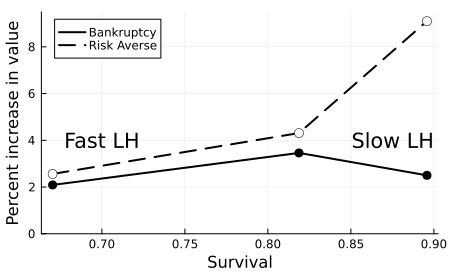

In [2]:
Survival = exp.(-1*[0.4, 0.2, 0.11])
Value_Bankruptcy = [2.09, 3.46, 2.50]
Value_risk_averse = [2.56, 4.31, 9.10]

plt = Plots.plot(Survival,Value_Bankruptcy, label = "Bankruptcy", color = "black", linewidth = 2)
Plots.scatter!(Survival,Value_Bankruptcy, label = "", color = "black", markersize = 5)
Plots.plot!(Survival,Value_risk_averse, label = "Risk Averse", color = "black", linestyle = :dash, linewidth = 2)
Plots.scatter!(Survival,Value_risk_averse, label = "", color = "white", markersize = 5)
Plots.plot!(size = (450,275), xlabel = "Survival", ylabel = "Percent increase in value")
Plots.annotate!([0.7, 0.875], [4, 4], [string("Fast LH"),string("Slow LH")], ylims = (0,9.5))
savefig("~/Documents/value_by_LH.png")
plt

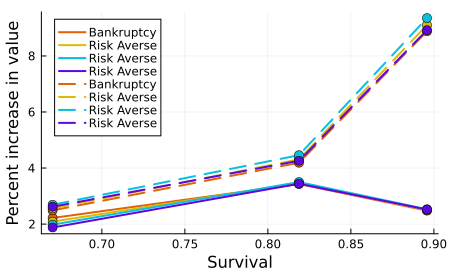

In [28]:
Survival = exp.(-1*[0.4, 0.2, 0.11])
Value_budget_025 = [2.22, 3.43, 2.48]
Value_budget_05 = [2.09, 3.46, 2.50]
Value_budget_1 = [1.98, 3.50, 2.53]
Value_budget_2 = [1.88, 3.44,2.52]

plt = Plots.plot(Survival,Value_budget_025, label = "Bankruptcy", color = "#de6407", linewidth = 2)
Plots.scatter!(Survival,Value_budget_025, label = "", color = "#de6407", markersize = 5)
Plots.plot!(Survival,Value_budget_05, label = "Risk Averse", color = "#deba07", linewidth = 2)
Plots.scatter!(Survival,Value_budget_05, label = "", color = "#deba07", markersize = 5)
Plots.plot!(Survival,Value_budget_1, label = "Risk Averse", color = "#07c1de", linewidth = 2)
Plots.scatter!(Survival,Value_budget_1, label = "", color = "#07c1de", markersize = 5)
Plots.plot!(Survival,Value_budget_2, label = "Risk Averse", color = "#5d07de",linewidth = 2)
Plots.scatter!(Survival,Value_budget_2, label = "", color = "#5d07de", markersize = 5)

Value_budget_025 = [2.49, 4.19, 8.88]
Value_budget_05 = [2.56, 4.31, 9.10]
Value_budget_1 = [2.69, 4.46, 9.35]
Value_budget_2 = [2.62, 4.26, 8.92]
Plots.plot!(Survival,Value_budget_025, label = "Bankruptcy", color = "#de6407", linewidth = 2, linestyle = :dash)
Plots.scatter!(Survival,Value_budget_025, label = "", color = "#de6407", markersize = 5)
Plots.plot!(Survival,Value_budget_05, label = "Risk Averse", color = "#deba07", linewidth = 2, linestyle = :dash)
Plots.scatter!(Survival,Value_budget_05, label = "", color = "#deba07", markersize = 5)
Plots.plot!(Survival,Value_budget_1, label = "Risk Averse", color = "#07c1de", linewidth = 2, linestyle = :dash)
Plots.scatter!(Survival,Value_budget_1, label = "", color = "#07c1de", markersize = 5)
Plots.plot!(Survival,Value_budget_2, label = "Risk Averse", color = "#5d07de",linewidth = 2, linestyle = :dash)
Plots.scatter!(Survival,Value_budget_2, label = "", color = "#5d07de", markersize = 5)

Plots.plot!(size = (450,275), xlabel = "Survival", ylabel = "Percent increase in value")
savefig("~/Documents/value_by_LH_budget.png")
plt

[ Info: Precompiling DataFramesExt [9e668153-f473-5010-85ff-a85cbe3b95ea]
┌ Warning: Module Latexify with build ID ffffffff-ffff-ffff-0000-9139879fd105 is missing from the cache.
│ This may mean Latexify [23fbe1c1-3f47-55db-b15f-69d7ec21a316] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing DataFramesExt [9e668153-f473-5010-85ff-a85cbe3b95ea].


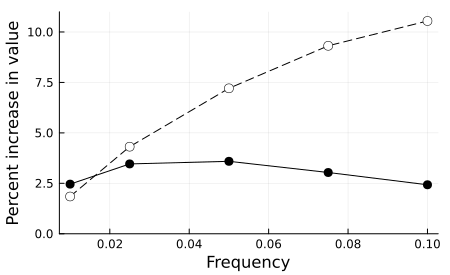

In [3]:
using CSV, DataFrames
df = CSV.read("../results/no_RA_intermidiate_lower_frequency/value_diff.csv",DataFrame)
df.frequency .= 0.01

df2 = CSV.read("../results/no_RA_intermidiate/value_diff.csv",DataFrame)
df2.frequency .= 0.025
df = vcat(df,df2)

df3 = CSV.read("../results/no_RA_intermidiate_higher_frequency/value_diff.csv",DataFrame)
df3.frequency .= 0.05
df = vcat(df,df3)

df3 = CSV.read("../results/no_RA_intermidiate_higher_frequency_2/value_diff.csv",DataFrame)
df3.frequency .= 0.075
df = vcat(df,df3)

df4 = CSV.read("../results/no_RA_intermidiate_higher_frequency_3/value_diff.csv",DataFrame)
df4.frequency .= 0.1
df = vcat(df,df4)


df_RA = CSV.read("../results/RA_intermidiate_lower_frequency/value_diff.csv",DataFrame)
df_RA.frequency .= 0.01

df2 = CSV.read("../results/RA_intermidiate/value_diff.csv",DataFrame)
df2.frequency .= 0.025
df_RA = vcat(df_RA,df2)

df3 = CSV.read("../results/RA_intermidiate_higher_frequency/value_diff.csv",DataFrame)
df3.frequency .= 0.05
df_RA = vcat(df_RA,df3)

df3 = CSV.read("../results/RA_intermidiate_higher_frequency_2/value_diff.csv",DataFrame)
df3.frequency .= 0.075
df_RA = vcat(df_RA,df3)

df4 = CSV.read("../results/RA_intermidiate_higher_frequency_3/value_diff.csv",DataFrame)
df4.frequency .= 0.1
df_RA = vcat(df_RA,df4)

plt=Plots.plot(df.frequency[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "", color = "black", linewidth = 1)
Plots.scatter!(df.frequency[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "", color = "black", markersize= 5, ylims = (0.0,4.0))
Plots.plot!(df_RA.frequency[df_RA.savings .== -1.5],df_RA.increase[df_RA.savings .== -1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dash)
Plots.scatter!(df_RA.frequency[df_RA.savings .== -1.5],df_RA.increase[df_RA.savings .== -1.5], 
            label = "", color = "white", markersize= 5, ylims = (0.0,11.0))
Plots.plot!(size = (450,275), xlabel = "Frequency", ylabel = "Percent increase in value")
savefig("~/Documents/value_by_risk.png")
plt

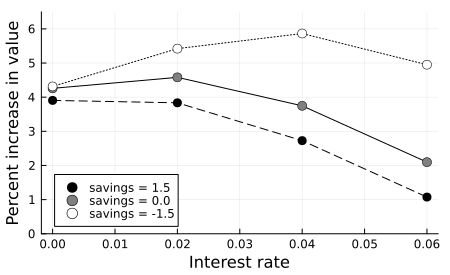

In [48]:
using CSV, DataFrames
df = CSV.read("../results/RA_intermidiate/value_diff.csv",DataFrame)
df.interest .= 0.0

df2 = CSV.read("../results/RA_intermidiate_higher_k/value_diff.csv",DataFrame)
df2.interest .= 0.02
df = vcat(df,df2)

df3 = CSV.read("../results/RA_intermidiate_higher_k_2/value_diff.csv",DataFrame)
df3.interest .= 0.04
df = vcat(df,df3)

df3 = CSV.read("../results/RA_intermidiate_higher_k_3/value_diff.csv",DataFrame)
df3.interest .= 0.06
df = vcat(df,df3)



plt=Plots.plot(df.interest[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dash)
Plots.scatter!(df.interest[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "savings = 1.5", color = "black", markersize= 5, ylims = (0.0,6.5))


Plots.plot!(df.interest[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "", color = "black", linewidth = 1)
Plots.scatter!(df.interest[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "savings = 0.0", color = "grey", markersize= 5, ylims = (0.0,6.5))

Plots.plot!(df.interest[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dot)
Plots.scatter!(df.interest[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "savings = -1.5", color = "white", markersize= 5, ylims = (0.0,6.5))

Plots.plot!(size = (450,275), xlabel = "Interest rate", 
            ylabel = "Percent increase in value", legendposition = :bottomleft)
savefig("~/Documents/value_by_interst_rate.png")
plt

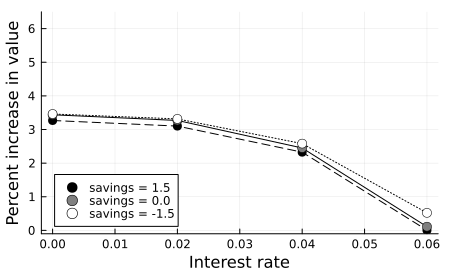

In [7]:
using CSV, DataFrames
df = CSV.read("../results/no_RA_intermidiate/value_diff.csv",DataFrame)
df.interest .= 0.0

df2 = CSV.read("../results/no_RA_intermidiate_higher_k/value_diff.csv",DataFrame)
df2.interest .= 0.02
df = vcat(df,df2)

df3 = CSV.read("../results/no_RA_intermidiate_higher_k_2/value_diff.csv",DataFrame)
df3.interest .= 0.04
df = vcat(df,df3)

df3 = CSV.read("../results/no_RA_intermidiate_higher_k_3/value_diff.csv",DataFrame)
df3.interest .= 0.06
df = vcat(df,df3)



plt=Plots.plot(df.interest[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dash)
Plots.scatter!(df.interest[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "savings = 1.5", color = "black", markersize= 5, ylims = (-0.1,6.5))

Plots.plot!(df.interest[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "", color = "black", linewidth = 1)
Plots.scatter!(df.interest[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "savings = 0.0", color = "grey", markersize= 5, ylims = (-0.1,6.5))

Plots.plot!(df.interest[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dot)
Plots.scatter!(df.interest[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "savings = -1.5", color = "white", markersize= 5, ylims = (-0.1,6.5))

Plots.plot!(size = (450,275), xlabel = "Interest rate", 
            ylabel = "Percent increase in value", legendposition = :bottomleft)
savefig("~/Documents/value_by_interst_rate_no_RA.png")
plt

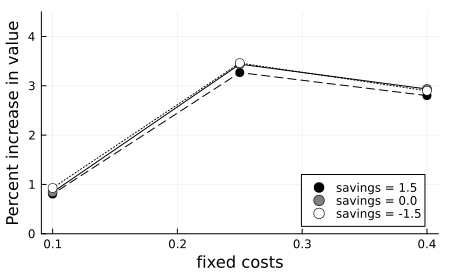

In [81]:
using CSV, DataFrames
df = CSV.read("../results/no_RA_intermidiate_lower_y0/value_diff.csv",DataFrame)
df.fixed_costs .= 0.4

df2 = CSV.read("../results/no_RA_intermidiate/value_diff.csv",DataFrame)
df2.fixed_costs .= 0.25
df = vcat(df,df2)

df3 = CSV.read("../results/no_RA_intermidiate_higher_y0/value_diff.csv",DataFrame)
df3.fixed_costs  .= 0.1
df = vcat(df,df3)


plt=Plots.plot(df.fixed_costs[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dash)
Plots.scatter!(df.fixed_costs[df.savings .== 1.5],df.increase[df.savings .== 1.5], 
            label = "savings = 1.5", color = "black", markersize= 5, ylims = (0.0,4.5))

Plots.plot!(df.fixed_costs[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "", color = "black", linewidth = 1)
Plots.scatter!(df.fixed_costs[df.savings .== 0.0],df.increase[df.savings .== 0.0], 
            label = "savings = 0.0", color = "grey", markersize= 5, ylims = (0.0,4.5))

Plots.plot!(df.fixed_costs[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "", color = "black", linewidth = 1, linestyle = :dot)
Plots.scatter!(df.fixed_costs[df.savings .== -1.5],df.increase[df.savings .== -1.5], 
            label = "savings = -1.5", color = "white", markersize= 5, ylims = (0.0,4.5))

Plots.plot!(size = (450,275), xlabel = "fixed costs", 
            ylabel = "Percent increase in value", legendposition = :bottomright)
savefig("~/Documents/value_by_interst_rate.png")
plt